In [ ]:
import numpy as np
num_arms = 10

q_star = np.random.normal(loc=0, scale=1, size=num_arms)
print(f"True action values (q_star): {q_star}")

def get_reward(arm_index):
    if not (0 <= arm_index < num_arms):
        raise ValueError(f"Arm index must be between 0 and {num_arms - 1}.")

    return np.random.normal(loc=q_star[arm_index], scale=1)

True action values (q_star): [ 0.28117315 -0.44866388 -0.45885031  1.53274833 -0.71111297  0.22712706
  1.46566765  0.47655413  0.28833029 -1.17487821]


In [ ]:
def epsilon_greedy_agent(epsilon, q_estimates, n_counts):

    if np.random.rand() < epsilon:
        chosen_arm = np.random.randint(num_arms)
    else:
        chosen_arm = np.argmax(q_estimates)

    reward = get_reward(chosen_arm)
    n_counts[chosen_arm] += 1
    q_estimates[chosen_arm] += (reward - q_estimates[chosen_arm]) / n_counts[chosen_arm]

    return chosen_arm, reward

In [ ]:
initial_q_value = 5
o_q_estimates = np.full(num_arms, initial_q_value)
o_n_counts = np.zeros(num_arms)

In [ ]:
def ucb_agent(c, time_step, q_estimates, n_counts):

    ucb_values = np.zeros(num_arms)
    for arm in range(num_arms):
        if n_counts[arm] == 0: # Prioritize unpulled arms
            ucb_values[arm] = np.inf
        else:
            confidence_bound = c * np.sqrt(np.log(time_step) / n_counts[arm])
            ucb_values[arm] = q_estimates[arm] + confidence_bound

    chosen_arm = np.argmax(ucb_values)
    reward = get_reward(chosen_arm)

    n_counts[chosen_arm] += 1
    q_estimates[chosen_arm] += (reward - q_estimates[chosen_arm]) / n_counts[chosen_arm]

    return chosen_arm, reward

print("UCB agent function defined.")

UCB agent function defined.


In [ ]:
num_time_steps = 1000
num_runs = 2000

rewards_epsilon_0 = np.zeros((num_runs, num_time_steps))
rewards_epsilon_0_01 = np.zeros((num_runs, num_time_steps))
rewards_epsilon_0_1 = np.zeros((num_runs, num_time_steps))
rewards_optimistic = np.zeros((num_runs, num_time_steps))
rewards_ucb = np.zeros((num_runs, num_time_steps))

for run in range(num_runs):

    eg0_q_estimates = np.zeros(num_arms)
    eg0_n_counts = np.zeros(num_arms)

    eg0_01_q_estimates = np.zeros(num_arms)
    eg0_01_n_counts = np.zeros(num_arms)

    eg0_1_q_estimates = np.zeros(num_arms)
    eg0_1_n_counts = np.zeros(num_arms)

    oi_q_estimates = np.full(num_arms, initial_q_value)
    oi_n_counts = np.zeros(num_arms)

    # UCB
    ucb_q_estimates = np.zeros(num_arms)
    ucb_n_counts = np.zeros(num_arms)

    for t in range(num_time_steps):
        # Epsilon-greedy (epsilon = 0)
        _, reward_eg0 = epsilon_greedy_agent(0, eg0_q_estimates, eg0_n_counts)
        rewards_epsilon_0[run, t] = reward_eg0

        # Epsilon-greedy (epsilon = 0.01)
        _, reward_eg0_01 = epsilon_greedy_agent(0.01, eg0_01_q_estimates, eg0_01_n_counts)
        rewards_epsilon_0_01[run, t] = reward_eg0_01

        # Epsilon-greedy (epsilon = 0.1)
        _, reward_eg0_1 = epsilon_greedy_agent(0.1, eg0_1_q_estimates, eg0_1_n_counts)
        rewards_epsilon_0_1[run, t] = reward_eg0_1

        # Optimistic Initialization (epsilon = 0 for greedy action selection)
        _, reward_oi = epsilon_greedy_agent(0, oi_q_estimates, oi_n_counts)
        rewards_optimistic[run, t] = reward_oi

        # UCB (c = 2)
        _, reward_ucb = ucb_agent(2, t + 1, ucb_q_estimates, ucb_n_counts)
        rewards_ucb[run, t] = reward_ucb

    if (run + 1) % 100 == 0:
        print(f"Completed {run + 1}/{num_runs} runs.")

Completed 100/2000 runs.
Completed 200/2000 runs.
Completed 300/2000 runs.
Completed 400/2000 runs.
Completed 500/2000 runs.
Completed 600/2000 runs.
Completed 700/2000 runs.
Completed 800/2000 runs.
Completed 900/2000 runs.
Completed 1000/2000 runs.
Completed 1100/2000 runs.
Completed 1200/2000 runs.
Completed 1300/2000 runs.
Completed 1400/2000 runs.
Completed 1500/2000 runs.
Completed 1600/2000 runs.
Completed 1700/2000 runs.
Completed 1800/2000 runs.
Completed 1900/2000 runs.
Completed 2000/2000 runs.


In [ ]:
avg_rewards_epsilon_0 = np.mean(rewards_epsilon_0, axis=0)
avg_rewards_epsilon_0_01 = np.mean(rewards_epsilon_0_01, axis=0)
avg_rewards_epsilon_0_1 = np.mean(rewards_epsilon_0_1, axis=0)
avg_rewards_optimistic = np.mean(rewards_optimistic, axis=0)
avg_rewards_ucb = np.mean(rewards_ucb, axis=0)

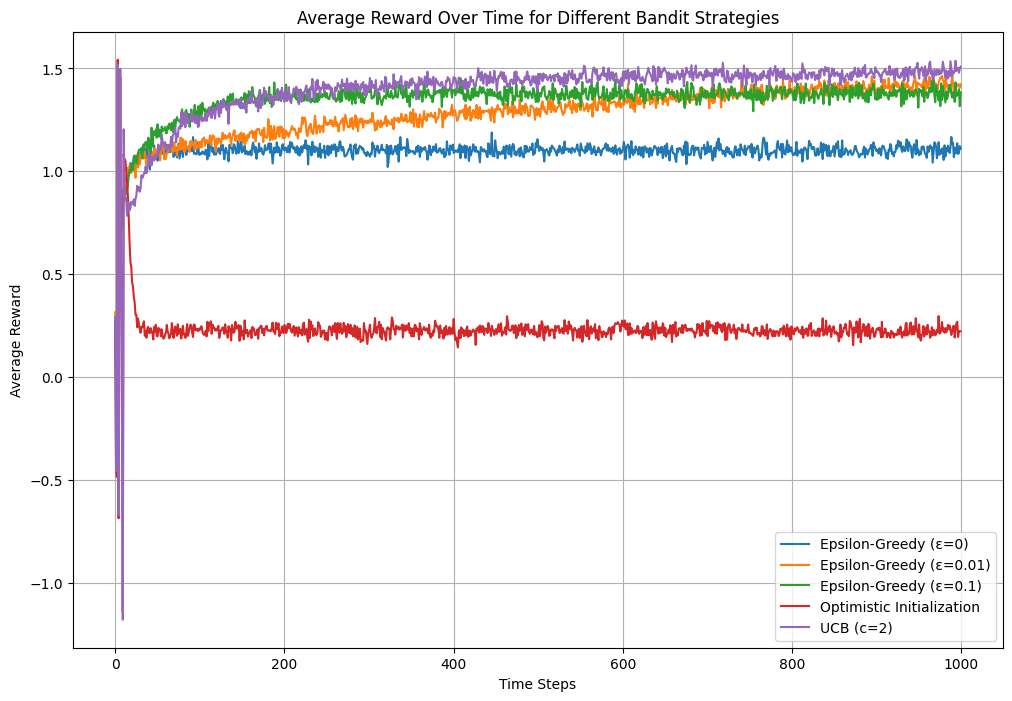

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.plot(avg_rewards_epsilon_0, label='Epsilon-Greedy (ε=0)')
plt.plot(avg_rewards_epsilon_0_01, label='Epsilon-Greedy (ε=0.01)')
plt.plot(avg_rewards_epsilon_0_1, label='Epsilon-Greedy (ε=0.1)')
plt.plot(avg_rewards_optimistic, label='Optimistic Initialization')
plt.plot(avg_rewards_ucb, label='UCB (c=2)')

plt.title('Average Reward Over Time for Different Bandit Strategies')
plt.xlabel('Time Steps')
plt.ylabel('Average Reward')

plt.legend()
plt.grid(True)
plt.show()